# Crashworthiness

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from control.matlab import step, impulse, ss
from control import forced_response

def landing_gear(M1,M2,K1,K2,B):
    
    A = np.array([[0, 1, 0, 0], [-K1/M1, -B/M1, K1/M1, B/M1],[0, 0, 0, 1],[K1/M2, B/M2, -(K1+K2)/M2, -B/M2]])
    
    B = np.array([[0],[0],[0],[1/M2]])
    
    C = np.array([[1, 0, 0, 0]])
    
    D = np.array([[0]])
    
    return ss(A,B,C,D)


<AxesSubplot:>

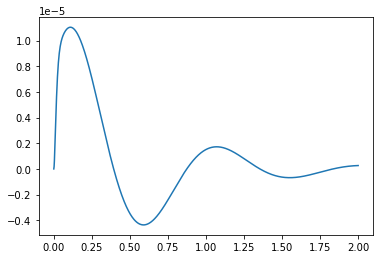

In [2]:
M1 = 1930   #airplane mass  [kg]
M2 = 50     # mass of 2 wheels (rear set)  -  research wheel mass - no data
K1 = 100000            #variable
K2 = 535323.6 # [N/m]   -   https://www.aircraftdesigns.com/design/gyroplanes/landing-gear-loads/
B = 10000   # [N/(m/s)]    #variable
# change K1 and B

sys = landing_gear(M1, M2, K1, K2, B)

#y1, t = step(H, t)       
y, t = impulse(sys, np.linspace(0, 2, 1000))
sns.lineplot(x=t, y=y)

$\vec{x} = [y_G, \alpha, \beta, \dot{y}_G, \dot{\alpha}, \dot{\beta}]^T$

$\vec{u} = [0, 0, 0, f(t), 0, 0]^T$

$\dot{\vec{x}} = A \cdot \vec{x} + B \cdot \vec{u}$

$\vec{y} = C \cdot \vec{x} + D \cdot \vec{u}$

In [3]:
import numpy as np
import control.matlab as c

def GearSystem(K, C, M, d, l1, l2):
    (k1, k2, k3), (c1, c2, c3), (m, Jx, Jz) = K, C, M

    #unknown = {'yG': [1, 0, 0]+[0]*3, 'alpha': [0, 1, 0]+[0]*3, 'beta': [0, 0, 1]+[0]*3,
    #          'yGd': [0]*3+[1, 0, 0], 'alphad': [0]*3+[0, 1, 0], 'betad': [0]*3+[0, 0, 1]}[uk]

    d3 = np.sqrt(l2 ** 2 - 0.25 * l1 ** 2) - d

    SFs = -(1/m) * np.array([k1 + k2 + k3, 0.5 * l1 * (k1 - k2), d * (k1 + k2) - d3 * k3,
                             c1 + c2 + c3, 0.5 * l1 * (c1 - c2), d * (c1 + c2) - d3 * c3])

    SMx = -(1/Jx) * np.array([0.5 * l1 * (k1 - k2), 0.25 * l1 ** 2 * (k1 + k2), (k1-k2)*d*l1*0.5,
                              0.5 * l1 * (c1 - c2), 0.25 * l1 ** 2 * (c1 + c2), (c1-c2)*d*l1*0.5])

    SMz = -(1/Jz) * np.array([d * (k1 + k2) - d3 * k3, 0.5 * l1 * d * (k1 - k2), d*d * (k1 + k2) + d3*d3 * k3,
                              d * (c1 + c2) - d3 * c3, 0.5 * l1 * d * (c1 - c2), d*d * (c1 + c2) + d3*d3 * c3])

    A = np.array([[0, 0, 0, 1, 0, 0],
                  [0, 0, 0, 0, 1, 0],
                  [0, 0, 0, 0, 0, 1],
                   SFs, SMx, SMz])

    B = np.array([[0, 0, 0, -1/m, 0, 0]]).T

    C = np.concatenate([np.identity(len(A))[:3, :], A])

    D = np.zeros([len(A)+3, 1])
    D[6][0] = -1/m

    return c.ss(A, B, C, D)


def SolveLandingGear(sys, imp, forc, t0, t1):
    yimp, t = c.impulse(sys, np.linspace(t0, t1, 1000), 0, 0)
    yforc, t = c.step(sys, t)
    return t, yimp * imp + forc * yforc

In [22]:
M1 = 1500
Vcrash = 9.9 #m/s
gmax = 7  # the classic g's on contact
Dtot = gmax*9.81*M1/Vcrash

gmax2 = 4 #g's on fullly compressed spring
gear_displacement = 0.4  # m
Ktot = gmax2*9.81 * M1 / gear_displacement




K = [Ktot/3]*3 # Spring constants k1, k2, k3 N/m
C = [Dtot/3]*3 # Damping coefficients c1, c2, c3 N/ms-1
d, l1, l2 = 1, 6, 10 # zcg, d landing gears, d2 landing gears [m]
M = M1, 10000, 10000 # m [kg], Jx [kgm2], Jz [kgm2]

(sys := GearSystem(K, C, M, d, l1, l2))

StateSpace(array([[   0.        ,    0.        ,    0.        ,    1.        ,
           0.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ,    0.        ,
           1.        ,    0.        ],
       [   0.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    1.        ],
       [ -98.1       ,   -0.        ,  213.83811886,   -6.93636364,
          -0.        ,   15.11986699],
       [  -0.        ,  -88.29      ,   -0.        ,   -0.        ,
          -6.24272727,   -0.        ],
       [  32.07571783,   -0.        , -367.48856434,    2.26798005,
          -0.        ,  -25.9840399 ]]), array([[ 0.        ],
       [ 0.        ],
       [ 0.        ],
       [-0.00066667],
       [ 0.        ],
       [ 0.        ]]), array([[   1.        ,    0.        ,    0.        ,    0.        ,
           0.        ,    0.        ],
       [   0.        ,    1.        ,    0.        ,    0.        ,
           0.        ,    0.        

<AxesSubplot:>

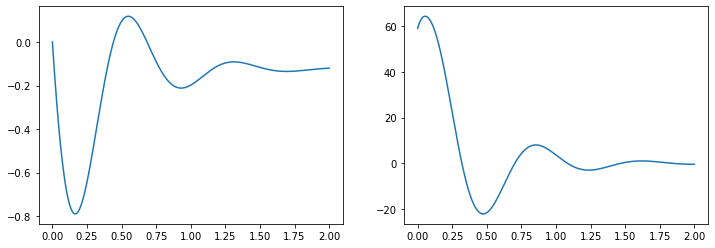

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
imp, forc = Vcrash*M1, M1*9.81 # N*s, N

tsim = 2

t, y = SolveLandingGear(sys, imp, forc, 0, tsim)
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
sns.lineplot(x=t, y=y[:, 0].T[0])
plt.subplot(1, 2, 2)
sns.lineplot(x=t, y=y[:, 6].T[0])